In [1]:
from google.colab import files
uploaded = files.upload()  # upload images.zip
!unzip images.zip

Saving images.zip to images.zip
Archive:  images.zip
   creating: images/
  inflating: images/yellow_light.jpg  
  inflating: __MACOSX/images/._yellow_light.jpg  
  inflating: images/green_light.jpg  
  inflating: __MACOSX/images/._green_light.jpg  
  inflating: images/red_light.jpg    
  inflating: __MACOSX/images/._red_light.jpg  


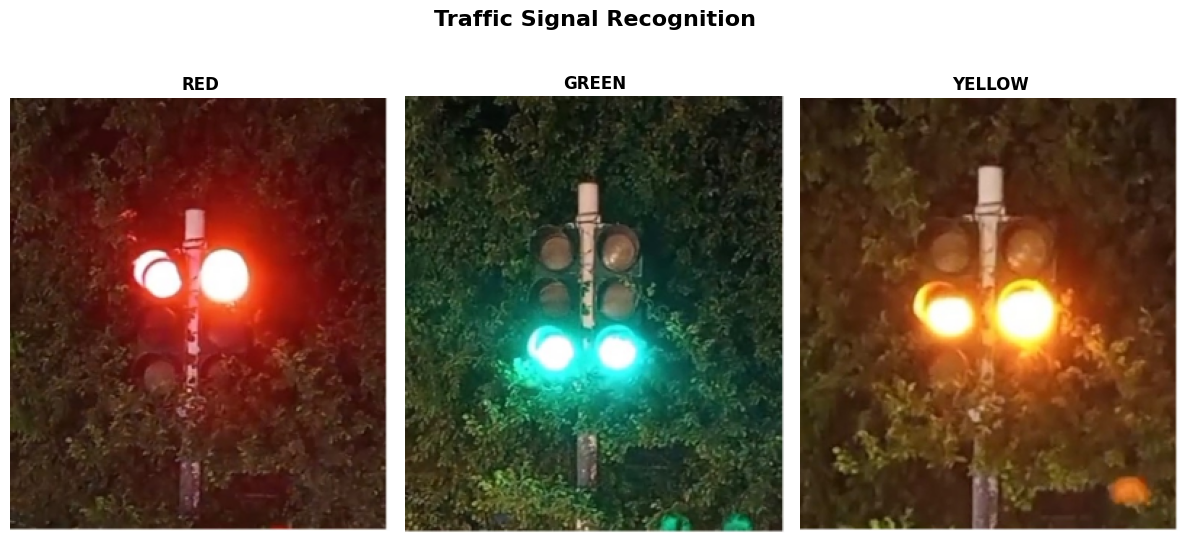

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import math

# Path to images folder
imgDir = "images"
files = glob.glob(os.path.join(imgDir, "*.jpg"))

n = len(files)
cols = 3   # three signals per row
rows = math.ceil(n / cols)

plt.figure(figsize=(12, 6))
plt.suptitle("Traffic Signal Recognition", fontsize=16, fontweight='bold')

for k, path in enumerate(files):
    # Read image
    I = cv2.imread(path)
    if I is None:
        continue

    # Resize
    h = 300
    scale = h / I.shape[0]
    w = int(I.shape[1] * scale)
    I = cv2.resize(I, (w, h))

    # Convert to HSV
    hsv = cv2.cvtColor(I, cv2.COLOR_BGR2HSV)
    H = hsv[:, :, 0] / 179.0
    S = hsv[:, :, 1] / 255.0
    V = hsv[:, :, 2] / 255.0

    # Thresholds
    redMask = ((H < 0.05) | (H > 0.95)) & (S > 0.4) & (V > 0.3)
    yellowMask = (H > 0.12) & (H < 0.18) & (S > 0.4) & (V > 0.3)
    greenMask = (H > 0.25) & (H < 0.50) & (S > 0.5) & (V > 0.4)

    # Count pixels
    redCount = np.sum(redMask)
    yellowCount = np.sum(yellowMask)
    greenCount = np.sum(greenMask)

    # Decide state
    counts = [redCount, yellowCount, greenCount]
    idx = int(np.argmax(counts))
    if idx == 0:
        state = "RED"
    elif idx == 1:
        state = "YELLOW"
    else:
        state = "GREEN"

    # Subplot
    plt.subplot(rows, cols, k + 1)
    plt.imshow(cv2.cvtColor(I, cv2.COLOR_BGR2RGB))
    plt.title(state, fontsize=12, fontweight='bold')
    plt.axis("off")

plt.tight_layout()
plt.show()
